# Face Recognition with OpenCV

Building on our previous blog wherein we covered the topic of face detection, we will now be using OpenCV to illustrate how not only can you use computers to detect faces, so too can you use them to recognize specific faces.

In [1]:
# @title Contact Software Sushi {"display-mode":"form"}
import base64
import requests
import urllib.request
from IPython.display import display, HTML

image_url = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/company/logo.png"
with urllib.request.urlopen(image_url) as response:
    image_data = response.read()
    encoded_image = base64.b64encode(image_data).decode()

def load_html_from_github(raw_url):
    response = requests.get(raw_url)
    html_content = response.text
    updated_html = html_content.replace('../images/logo.png', f"data:image/png;base64, {encoded_image}")
    display(HTML(updated_html))

load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner-with-logo.html')

###Imports & Sample Images###

In [2]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import base64
import os

from IPython.display import HTML, display
from io import BytesIO
from PIL import Image

In [ ]:
!pip uninstall opencv-python opencv-contrib-python -y
!pip install opencv-python opencv-contrib-python==4.10.0.84 --force-reinstall

Found existing installation: opencv-python 4.12.0.88
Uninstalling opencv-python-4.12.0.88:
  Successfully uninstalled opencv-python-4.12.0.88
Found existing installation: opencv-contrib-python 4.12.0.88
Uninstalling opencv-contrib-python-4.12.0.88:
  Successfully uninstalled opencv-contrib-python-4.12.0.88
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 62.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the foll

### Utils

In [3]:
# Function for the creation of flexible MatPlotLib figures
def create_mpl_figure(w,h,images,titles="Image",axis="off",color_maps=None):
    plt.figure(figsize=[w,h])

    for i, image in enumerate(images):
        plt.subplot(1,len(images),i+1);

        if color_maps is None:
            plt.imshow(image);
        elif len(color_maps) > 1:
            plt.imshow(image, cmap=f"{color_maps[i]}");
        else:
            plt.imshow(image, cmap=f"{color_maps[0]}")

        plt.title(titles[i]);
        plt.axis(axis);

## Face Recognition Process

Unlike face detection, which was demonstrated in the previous blog, facial recognition is quite a bit more complex than using a pre-built method in OpenCV to process images. This blog will illustrate the use of the Local Binary Pattern Histogram (LBPH) method. This process functions by first taking as an input a face then dividing that face into a grid of small regions. From there, binary patterns are extracted by comparing each pixel within the small region to its neighboring pixels. Histograms are then created for each region, and finally, the histograms for every single region is concatenated to a vector representative of the particular face.

## Use Cases

Face Recognition is used all the time, whether it be for biometric authentication, use in Law Enforcement scenarios through CCTV, or a variety of other circumstances. The uses for it are growing consistently, and show no sign of slowing down.

## Utilizing Local Binary Pattern Histograms with an Existing Dataset

### Fetching our sample faces

Unlike the previous blog, where we detected faces within a given image, we will be using an existing dataset of 400 images of 40 different faces at 10 images per face. If one were to instead want to do this with their own dataset, all of the same steps can be followed, just substituting the sample data with their own. For this purpose then, it is unnecessary to use Haar Cascades to first detect the faces, since the images are all cropped faces.

In [ ]:
#Retrieving our sample faces
!wget https://www.cl.cam.ac.uk/Research/DTG/attarchive/pub/data/att_faces.zip

!mkdir -p faces
!unzip -q att_faces.zip -d faces

--2025-07-24 23:13:09--  https://www.cl.cam.ac.uk/Research/DTG/attarchive/pub/data/att_faces.zip
Resolving www.cl.cam.ac.uk (www.cl.cam.ac.uk)... 128.232.0.20, 2a05:b400:110::80:14
Connecting to www.cl.cam.ac.uk (www.cl.cam.ac.uk)|128.232.0.20|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.cl.cam.ac.uk/research/dtg/attarchive/pub/data/att_faces.zip [following]
--2025-07-24 23:13:09--  https://www.cl.cam.ac.uk/research/dtg/attarchive/pub/data/att_faces.zip
Reusing existing connection to www.cl.cam.ac.uk:443.
HTTP request sent, awaiting response... 200 OK
Length: 3769022 (3.6M) [application/zip]
Saving to: ‘att_faces.zip’

att_faces.zip       100%[===================>]   3.59M  4.09MB/s    in 0.9s    

2025-07-24 23:13:10 (4.09 MB/s) - ‘att_faces.zip’ saved [3769022/3769022]



### Preparing the Data

After retrieving our face images, we now need to transform them into a usable format for the LBPH process. If you look closely, you will notice that of our sample size of 10 photos per person, 9 are fed to the recognizer, while 1 is held back, which will allow us to properly test later on whether or not the recognizer is able to accurately determine whether or not it recognizes a face.

In [ ]:
base_path = 'faces'
test_faces = []
test_labels = []
faces = []
labels = []

for label in range(1, 41):  # 40 people
    for i in range(1, 11):  # 10 images per person
        img_path = f'{base_path}/s{label}/{i}.pgm'
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if i == 10:
            # Withhold the 10th image of each person for testing
            test_faces.append(img)
            test_labels.append(label)
        else:
            faces.append(img)
            labels.append(label)

### Training Using the Faces

Now that we have our faces downloaded, we need to train the recognizer to actually be able to see and recognize each of the 10 different faces. In order to do this, we needed to install a wrapper package called opencv-contrib-python. This library contains the cv2.face property, which we need to access for the training of the recognizer. It is worth noting here that when using the LBPH model to do facial recognition, the labels that you pass to the recognizer must be integers. It will throw an error if any other data type is passed as a label.

In [ ]:
import cv2.face

recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(faces, np.array(labels))

### Testing the Recognizer

Now that we have fed the recognizer 9 pictures for each face, we will take the test faces and display them side by side to see how the recognizer does in ascertaining whether it recognizes a given face. It is very important to note here that confidence scoring in the LBPH method is an inverse to what one might normally assume. The reason for this is that though "confidence" is the word put forth in OpenCV documentation, in reality what this is measuring is the distance between two things, namely, the histograms of the images on which the model was trained, and the histogram of the new image it is being fed. This is the reason why lower values indicate higher "confidence", because the distance between the two histograms is much lower, indicating that it is far more likely to be one of faces on which the model was trained.

Higher numbers = Lower confidence (100<=)
Lower numbers = Higher confidence (<=50)

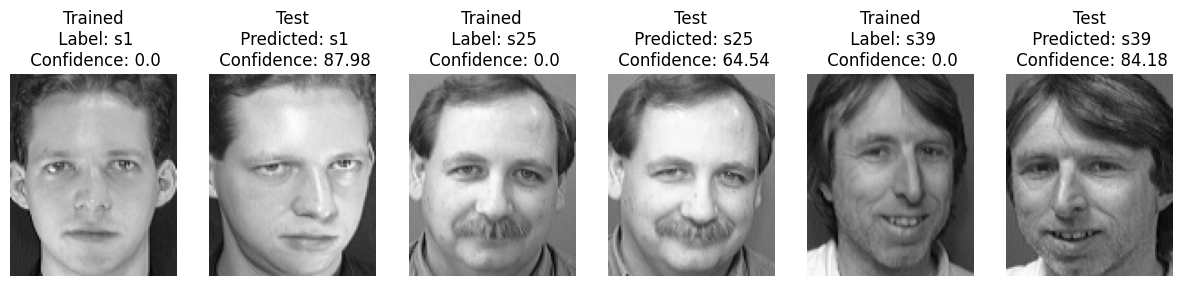

In [ ]:
# Locate image paths
trained_paths = ['faces/s1/1.pgm', 'faces/s25/6.pgm', 'faces/s39/2.pgm']
test_paths = ['faces/s1/10.pgm', 'faces/s25/10.pgm', 'faces/s39/10.pgm']

# Create two lists to house training images and testing images
trained_imgs = []
test_imgs = []

for (trained_path, test_path) in zip(trained_paths, test_paths):
    trained_img = cv2.imread(trained_path, cv2.IMREAD_GRAYSCALE)
    test_img = cv2.imread(test_path, cv2.IMREAD_GRAYSCALE)

    trained_imgs.append(trained_img)
    test_imgs.append(test_img)

# Create two lists to house labels and confidence ratings
labels = []
conf = []

for (trained_img, test_img) in zip(trained_imgs, test_imgs):
    trained_label, trained_conf = recognizer.predict(trained_img)
    test_label, test_conf = recognizer.predict(test_img)

    labels.append(trained_label)
    labels.append(test_label)

    conf.append(trained_conf)
    conf.append(test_conf)

# Create two final lists to contain both trained and test images,
# as well as a list to include image titles to feed to the MatPlotLib function
imgs = []
img_titles = []

for trained_img, test_img in zip(trained_imgs, test_imgs):
    imgs.append(trained_img)
    imgs.append(test_img)

for idx, (label, confidence) in enumerate(zip(labels, conf)):
    if idx % 2 == 0:
        img_titles.append(f'Trained\n Label: s{label}\n Confidence: {round(confidence, 2)}')
    else:
        img_titles.append(f'Test\n Predicted: s{label}\n Confidence: {round(confidence, 2)}')

create_mpl_figure(15, 10, imgs, img_titles, color_maps=["gray"])

## Utilizing Local Binary Pattern Histograms with a Custom Dataset

Now that the LBPH process has been demonstrated using a pre-built dataset, the use of LBPH will now be demonstrated using a custom dataset created in the next few blocks of code.

### Image Collection & Pre-Processing

To begin, we first need to fetch the images that will be composing both our training set and our testing set

#### Fetching Training and Testing Images

In [5]:
# Fetching training and testing images
# Robert Downey Junior Sample Images
rdj_url_1 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/rdj_1.jpg"
rdj_resp_1 = urllib.request.urlopen(rdj_url_1)
rdj_bytes_1 = np.asarray(bytearray(rdj_resp_1.read()), dtype=np.uint8)

rdj_url_2 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/rdj_2.jpg"
rdj_resp_2 = urllib.request.urlopen(rdj_url_2)
rdj_bytes_2 = np.asarray(bytearray(rdj_resp_2.read()), dtype=np.uint8)

rdj_url_3 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/rdj_3.jpg"
rdj_resp_3 = urllib.request.urlopen(rdj_url_3)
rdj_bytes_3 = np.asarray(bytearray(rdj_resp_3.read()), dtype=np.uint8)

rdj_url_4 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/rdj_4.jpg"
rdj_resp_4 = urllib.request.urlopen(rdj_url_4)
rdj_bytes_4 = np.asarray(bytearray(rdj_resp_4.read()), dtype=np.uint8)

rdj_url_5 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/rdj_5.jpg"
rdj_resp_5 = urllib.request.urlopen(rdj_url_5)
rdj_bytes_5 = np.asarray(bytearray(rdj_resp_5.read()), dtype=np.uint8)

rdj_url_6 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/rdj_6.jpg"
rdj_resp_6 = urllib.request.urlopen(rdj_url_6)
rdj_bytes_6 = np.asarray(bytearray(rdj_resp_6.read()), dtype=np.uint8)

rdj_url_7 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/rdj_7.jpg"
rdj_resp_7 = urllib.request.urlopen(rdj_url_7)
rdj_bytes_7 = np.asarray(bytearray(rdj_resp_7.read()), dtype=np.uint8)

rdj_url_8 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/rdj_8.jpg"
rdj_resp_8 = urllib.request.urlopen(rdj_url_8)
rdj_bytes_8 = np.asarray(bytearray(rdj_resp_8.read()), dtype=np.uint8)

rdj_url_9 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/rdj_9.jpg"
rdj_resp_9 = urllib.request.urlopen(rdj_url_9)
rdj_bytes_9 = np.asarray(bytearray(rdj_resp_9.read()), dtype=np.uint8)

rdj_url_test = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/rdj_test.jpg"
rdj_resp_test = urllib.request.urlopen(rdj_url_test)
rdj_bytes_test = np.asarray(bytearray(rdj_resp_test.read()), dtype=np.uint8)

# Christian Bale Sample Images
cb_url_1 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/cb_1.jpg"
cb_resp_1 = urllib.request.urlopen(cb_url_1)
cb_bytes_1 = np.asarray(bytearray(cb_resp_1.read()), dtype=np.uint8)

cb_url_2 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/cb_2.jpg"
cb_resp_2 = urllib.request.urlopen(cb_url_2)
cb_bytes_2 = np.asarray(bytearray(cb_resp_2.read()), dtype=np.uint8)

cb_url_3 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/cb_3.jpg"
cb_resp_3 = urllib.request.urlopen(cb_url_3)
cb_bytes_3 = np.asarray(bytearray(cb_resp_3.read()), dtype=np.uint8)

cb_url_4 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/cb_4.jpg"
cb_resp_4 = urllib.request.urlopen(cb_url_4)
cb_bytes_4 = np.asarray(bytearray(cb_resp_4.read()), dtype=np.uint8)

cb_url_5 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/cb_5.jpg"
cb_resp_5 = urllib.request.urlopen(cb_url_5)
cb_bytes_5 = np.asarray(bytearray(cb_resp_5.read()), dtype=np.uint8)

cb_url_6 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/cb_6.jpg"
cb_resp_6 = urllib.request.urlopen(cb_url_6)
cb_bytes_6 = np.asarray(bytearray(cb_resp_6.read()), dtype=np.uint8)

cb_url_7 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/cb_7.jpg"
cb_resp_7 = urllib.request.urlopen(cb_url_7)
cb_bytes_7 = np.asarray(bytearray(cb_resp_7.read()), dtype=np.uint8)

cb_url_8 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/cb_8.jpg"
cb_resp_8 = urllib.request.urlopen(cb_url_8)
cb_bytes_8 = np.asarray(bytearray(cb_resp_8.read()), dtype=np.uint8)

cb_url_9 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/cb_9.jpg"
cb_resp_9 = urllib.request.urlopen(cb_url_9)
cb_bytes_9 = np.asarray(bytearray(cb_resp_9.read()), dtype=np.uint8)

cb_url_test = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/cb_test.jpg"
cb_resp_test = urllib.request.urlopen(cb_url_test)
cb_bytes_test = np.asarray(bytearray(cb_resp_test.read()), dtype=np.uint8)

# Pedro Pascal Sample Images
pp_url_1 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/pp_1.jpg"
pp_resp_1 = urllib.request.urlopen(pp_url_1)
pp_bytes_1 = np.asarray(bytearray(pp_resp_1.read()), dtype=np.uint8)

pp_url_2 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/pp_2.jpg"
pp_resp_2 = urllib.request.urlopen(pp_url_2)
pp_bytes_2 = np.asarray(bytearray(pp_resp_2.read()), dtype=np.uint8)

pp_url_3 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/pp_3.jpg"
pp_resp_3 = urllib.request.urlopen(pp_url_3)
pp_bytes_3 = np.asarray(bytearray(pp_resp_3.read()), dtype=np.uint8)

pp_url_4 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/pp_4.jpg"
pp_resp_4 = urllib.request.urlopen(pp_url_4)
pp_bytes_4 = np.asarray(bytearray(pp_resp_4.read()), dtype=np.uint8)

pp_url_5 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/pp_5.jpg"
pp_resp_5 = urllib.request.urlopen(pp_url_5)
pp_bytes_5 = np.asarray(bytearray(pp_resp_5.read()), dtype=np.uint8)

pp_url_6 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/pp_6.jpg"
pp_resp_6 = urllib.request.urlopen(pp_url_6)
pp_bytes_6 = np.asarray(bytearray(pp_resp_6.read()), dtype=np.uint8)

pp_url_7 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/pp_7.jpg"
pp_resp_7 = urllib.request.urlopen(pp_url_7)
pp_bytes_7 = np.asarray(bytearray(pp_resp_7.read()), dtype=np.uint8)

pp_url_8 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/pp_8.jpg"
pp_resp_8 = urllib.request.urlopen(pp_url_8)
pp_bytes_8 = np.asarray(bytearray(pp_resp_8.read()), dtype=np.uint8)

pp_url_9 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/pp_9.jpg"
pp_resp_9 = urllib.request.urlopen(pp_url_9)
pp_bytes_9 = np.asarray(bytearray(pp_resp_9.read()), dtype=np.uint8)

pp_url_test = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/facial_recognition/pp_test.jpg"
pp_resp_test = urllib.request.urlopen(pp_url_test)
pp_bytes_test = np.asarray(bytearray(pp_resp_test.read()), dtype=np.uint8)


# Converting a format that can be readily displayed & creating lists for pre-processing
# Robert Downey Junior Images
rdj_1 = cv2.cvtColor(cv2.imdecode(rdj_bytes_1, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
rdj_2 = cv2.cvtColor(cv2.imdecode(rdj_bytes_2, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
rdj_3 = cv2.cvtColor(cv2.imdecode(rdj_bytes_3, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
rdj_4 = cv2.cvtColor(cv2.imdecode(rdj_bytes_4, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
rdj_5 = cv2.cvtColor(cv2.imdecode(rdj_bytes_5, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
rdj_6 = cv2.cvtColor(cv2.imdecode(rdj_bytes_6, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
rdj_7 = cv2.cvtColor(cv2.imdecode(rdj_bytes_7, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
rdj_8 = cv2.cvtColor(cv2.imdecode(rdj_bytes_8, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
rdj_9 = cv2.cvtColor(cv2.imdecode(rdj_bytes_9, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

rdj_train_rgb_original = [rdj_1, rdj_2, rdj_3, rdj_4, rdj_5, rdj_6, rdj_7, rdj_8, rdj_9]

rdj_test = cv2.cvtColor(cv2.imdecode(rdj_bytes_test, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

# Christian Bale Images
cb_1 = cv2.cvtColor(cv2.imdecode(cb_bytes_1, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
cb_2 = cv2.cvtColor(cv2.imdecode(cb_bytes_2, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
cb_3 = cv2.cvtColor(cv2.imdecode(cb_bytes_3, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
cb_4 = cv2.cvtColor(cv2.imdecode(cb_bytes_4, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
cb_5 = cv2.cvtColor(cv2.imdecode(cb_bytes_5, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
cb_6 = cv2.cvtColor(cv2.imdecode(cb_bytes_6, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
cb_7 = cv2.cvtColor(cv2.imdecode(cb_bytes_7, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
cb_8 = cv2.cvtColor(cv2.imdecode(cb_bytes_8, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
cb_9 = cv2.cvtColor(cv2.imdecode(cb_bytes_9, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

cb_train_rgb_original = [cb_1, cb_2, cb_3, cb_4, cb_5, cb_6, cb_7, cb_8, cb_9]

cb_test = cv2.cvtColor(cv2.imdecode(cb_bytes_test, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

# Pedro Pascal Images
pp_1 = cv2.cvtColor(cv2.imdecode(pp_bytes_1, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
pp_2 = cv2.cvtColor(cv2.imdecode(pp_bytes_2, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
pp_3 = cv2.cvtColor(cv2.imdecode(pp_bytes_3, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
pp_4 = cv2.cvtColor(cv2.imdecode(pp_bytes_4, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
pp_5 = cv2.cvtColor(cv2.imdecode(pp_bytes_5, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
pp_6 = cv2.cvtColor(cv2.imdecode(pp_bytes_6, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
pp_7 = cv2.cvtColor(cv2.imdecode(pp_bytes_7, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
pp_8 = cv2.cvtColor(cv2.imdecode(pp_bytes_8, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
pp_9 = cv2.cvtColor(cv2.imdecode(pp_bytes_9, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

pp_train_rgb_original = [pp_1, pp_2, pp_3, pp_4, pp_5, pp_6, pp_7, pp_8, pp_9]

pp_test = cv2.cvtColor(cv2.imdecode(pp_bytes_test, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

# Add all images to one training list, add test images to one list
train_rgb_original = rdj_train_rgb_original + cb_train_rgb_original + pp_train_rgb_original
test_rgb_original = [rdj_test, cb_test, pp_test]

#### Color Conversions

After fetching the images, they need to be converted to grayscale, as this is one of the pre-processing steps required not only face-detection, but also for facial recognition.

In [6]:
# Creating lists to contain grayscale instances of training and testing images
train_grayscale = []
test_grayscale = []

# Appending new grayscale images to the list
for img in train_rgb_original:
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    train_grayscale.append(gray_img)

for img in test_rgb_original:
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    test_grayscale.append(gray_img)

#### Haar Cascade Classifier Face Detection

Now that we have grayscale versions of our training and testing images, they can be fed to the Haar Cascade Classifier to do the actual process of facial detection. At the end of this code block, for the sake of visualizing what is happening in this step, I have included the training and testing images with the detected faces drawn on each.

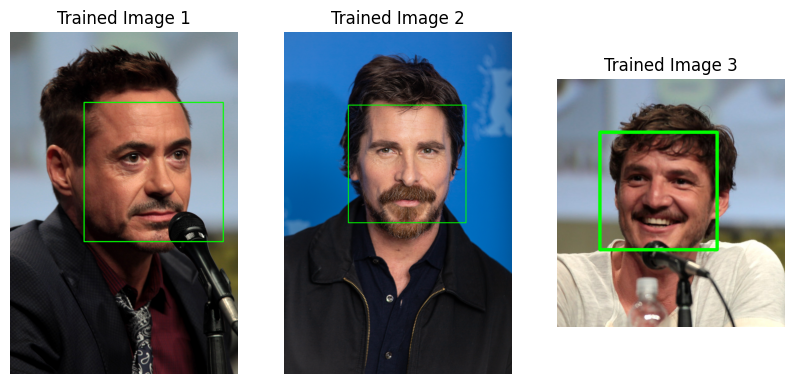

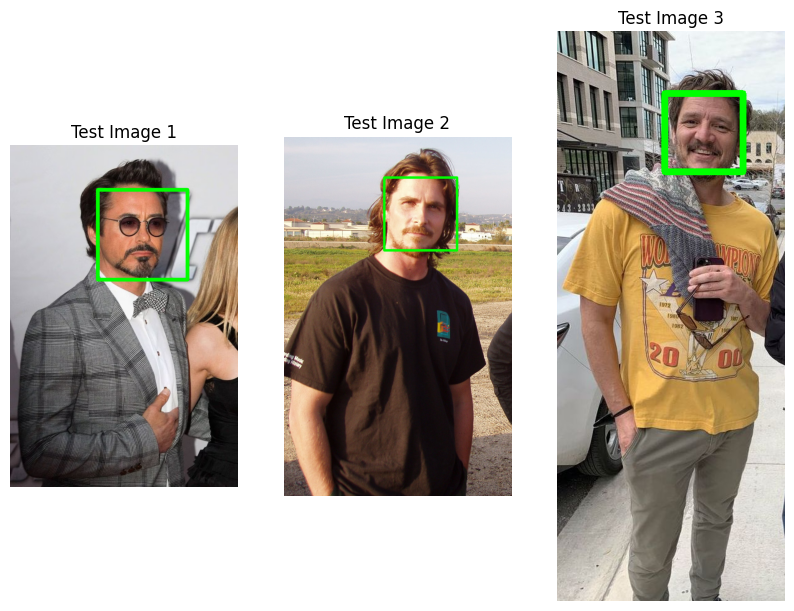

In [7]:
# Creating lists to contain the facial dimensions of the training and testing image sets
# Creating copies of training and testing images to draw detected faces on for visualization
train_dimensions = []
test_dimensions = []
train_rgb_edit = train_rgb_original.copy()
test_rgb_edit = test_rgb_original.copy()
example_images = []
example_dimensions = []

# Preparing the HCC for facial detection
frontal_face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Detecting faces (if any) on all training and testing images, storing dimensions of each face
for i, img in enumerate(train_grayscale):
    if i == 0 or i == 9 or i == 18:
        bounding_box_dimensions = frontal_face_cascade.detectMultiScale(img, scaleFactor=1.2, minNeighbors=8)
        train_dimensions.append(bounding_box_dimensions)
        example_dimensions.append(bounding_box_dimensions)
    else:
        bounding_box_dimensions = frontal_face_cascade.detectMultiScale(img, scaleFactor=1.2, minNeighbors=8)
        train_dimensions.append(bounding_box_dimensions)

for img in test_grayscale:
    bounding_box_dimensions = frontal_face_cascade.detectMultiScale(img, scaleFactor=1.2, minNeighbors=10)
    test_dimensions.append(bounding_box_dimensions)

# Drawing the detected faces bounding boxes on testing and training images
# Though irritating, the differing bounding box widths are due to image resolution,
# So aside from changing on a case by case basis, each of them will have different widths
for i, img in enumerate(train_rgb_edit):
    if i == 0 or i == 9 or i == 18:
        example_images.append(img)
    for (x, y, w, h) in train_dimensions[i]:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 10)

for i, img in enumerate(test_rgb_edit):
    for (x, y, w, h) in test_dimensions[i]:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 10)

# Creating lists of titles for displaying training and testing images with bounding boxes drawn
example_trained_titles = []
example_tested_titles = []

for i in range(len(example_images)):
    example_trained_titles.append(f'Trained Image {i+1}')

for i in range(len(test_rgb_edit)):
    example_tested_titles.append(f'Test Image {i+1}')

create_mpl_figure(10, 10, example_images, example_trained_titles)
create_mpl_figure(10, 10, test_rgb_edit, example_tested_titles)

#### Cropping the Training and Testing Images

Now that we have the dimensions for each face on the training and testing sets stored, we can crop our grayscale images using these dimensions, so that when we feed the training and testing sets to the recognizer, they will look similar to those of the first dataset we used, namely, small grayscale images only of a subjects face.

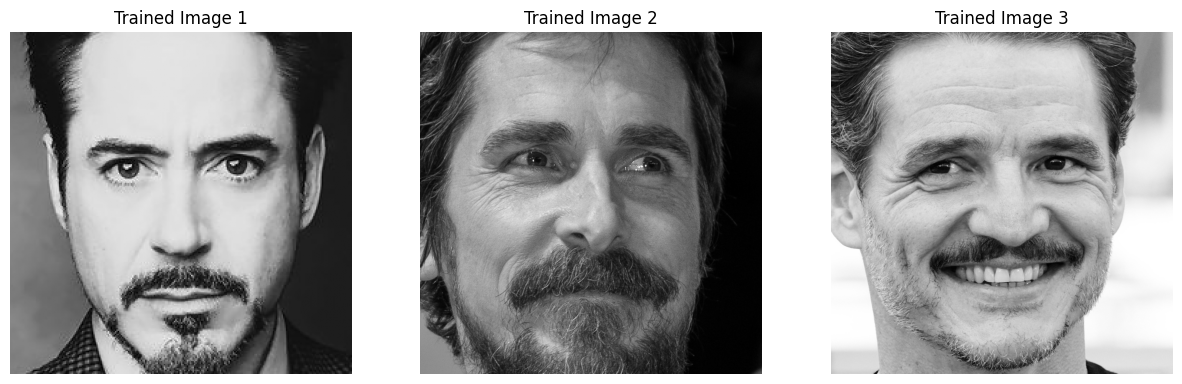

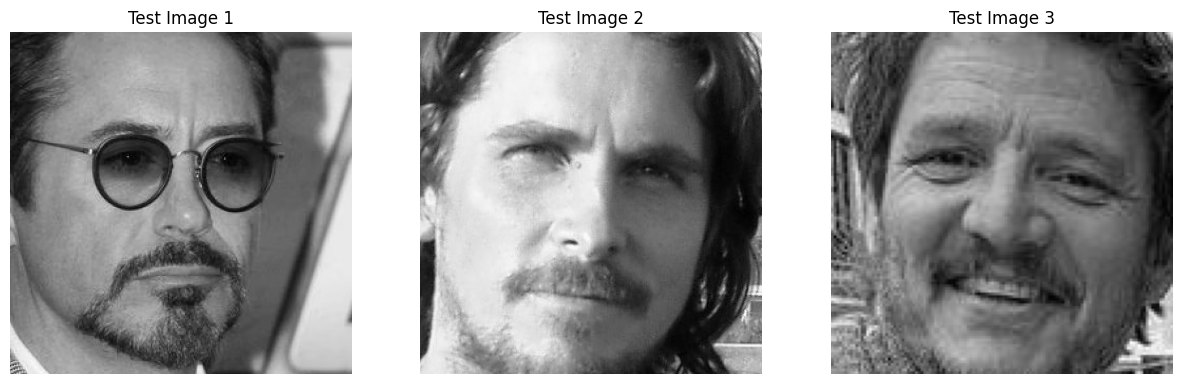

In [8]:
# Create lists that will contain cropped versions of the training and testing images
train_grayscale_cropped = []
test_grayscale_cropped = []

# Crop training images and store in according list
for i, img in enumerate(train_grayscale):
    if len(train_dimensions[i]) > 0:
        (x, y, w, h) = train_dimensions[i][0]
        cropped_face = img[y:y+h, x:x+w]
        train_grayscale_cropped.append(cropped_face)
    else:
        train_grayscale_cropped.append(img)

# Crop testing images and store in according list
for i, img in enumerate(test_grayscale):
    if len(test_dimensions[i]) > 0:
        (x, y, w, h) = test_dimensions[i][0]
        cropped_face = img[y:y+h, x:x+w]
        test_grayscale_cropped.append(cropped_face)
    else:
        test_grayscale_cropped.append(img)

# Create titles for grayscale cropped images
train_titles = ['Trained Image 1', 'Trained Image 2', 'Trained Image 3']
test_titles = []

for i in range(len(test_grayscale_cropped)):
    test_titles.append(f'Test Image {i+1}')

create_mpl_figure(15, 10, [train_grayscale_cropped[1], train_grayscale_cropped[10], train_grayscale_cropped[20]], train_titles, color_maps=["gray"])
create_mpl_figure(15, 10, test_grayscale_cropped, test_titles, color_maps=["gray"])

### Recognizer Training & Facial Recognition

We are almost there! Now that we have cropped and prepared both our training and testing data sets, we have what we need to first train the recognizer using the training dataset, and then test the recognizer's ability to predict that on which it was trained!

#### Training the Recognizer

Like before, we train the recognizer on our dataset. This time, we created our own label, one for each of the three subjects within the dataset.

In [9]:
# Create labels for the training dataset
rdj_labels = [1] * 9
cb_labels = [2] * 9
pp_labels = [3] * 9
train_labels = rdj_labels + cb_labels + pp_labels

# Recreate the recognizer from earlier so as to avoid any cross-contamination of data from the previous dataset
import cv2.face

recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(train_grayscale_cropped, np.array(train_labels))

#### Testing the Recognizer

Finally, we will give the recognizer an image of each of the three subjects that it was trained on as control images, and then testing images for each of the three subjects to see if it can discern which test image is of each of the three subjects.

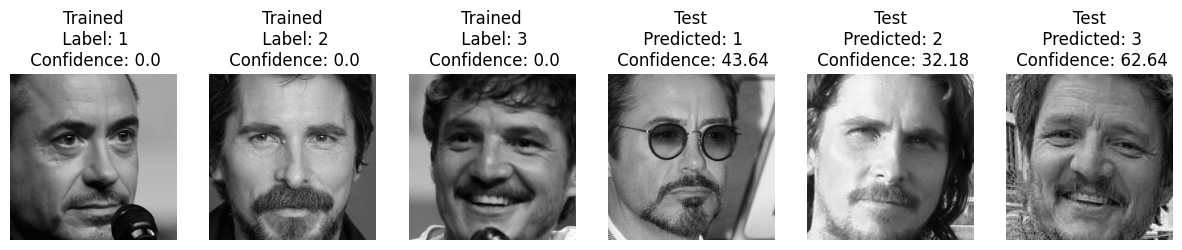

In [10]:
# Create two lists to house labels and confidence ratings
labels = []
conf = []

# Create one list to house one image from the training set, and the whole testing set
# Create another list for the titles that will be given to the images in the MatPlotLib figure
imgs_final = [train_grayscale_cropped[0], train_grayscale_cropped[9], train_grayscale_cropped[18]]
img_titles_final = []

for img in test_grayscale_cropped:
    imgs_final.append(img)

# Run the final images through the recognizer
for img in imgs_final:
    label, confidence = recognizer.predict(img)
    labels.append(label)
    conf.append(confidence)

# Label each image
for idx, (label, confidence) in enumerate(zip(labels, conf)):
    if idx < 3:
        img_titles_final.append(f'Trained\n Label: {label}\n Confidence: {round(confidence, 2)}')
    else:
        img_titles_final.append(f'Test\n Predicted: {label}\n Confidence: {round(confidence, 2)}')

create_mpl_figure(15, 10, imgs_final, img_titles_final, color_maps=["gray"])

## Conclusion

That is how you implement facial recognition using OpenCV! Though a bit more complex than face detection, once the rudiments of the process are understood, its flexibility and usefulness become readily apparent. In the final blog, we will be shifting gears from OpenCV to the current standard in real time object detection, YOLO!

## Credits

The face images used in this project are from the ORL Database of Faces, originally maintained by AT&T Laboratories Cambridge.

The dataset contains 400 grayscale images of 40 individuals, each with 10 different poses or expressions.

Dataset source: https://www.cl.cam.ac.uk/research/dtg/attarchive/facedatabase.html

The dataset is provided for research and educational use only.

In [ ]:
# @title Contact Software Sushi
load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner.html')